# 3.5 Reducción de Dimensionalidad y Manifold Learning

## 🎯 Objetivos
- Entender diferencias entre reducción lineal (PCA) y no lineal (t-SNE, UMAP, Isomap).
- Aplicar PCA para compresión y preprocesamiento.
- Interpretar varianza explicada y elegir nº de componentes.
- Visualizar datos de alta dimensión en 2D/3D.
- Comparar t-SNE, UMAP e Isomap sobre datasets con estructura no lineal.
- Conocer buenas prácticas y trampas comunes (t-SNE interpretabilidad limitada).

---
## 1. Motivación 💡
Reducción de dimensionalidad busca representar datos de alta dimensión en menos dimensiones preservando estructura relevante (varianza, proximidad local, geodésica). Beneficios:
- Visualización.
- Reducción de ruido.
- Acelerar modelos downstream.
- Mitigar maldición de dimensionalidad.

---
## 2. Técnicas y Enfoques
| Técnica | Tipo | Preserva | Parámetros Clave | Uso Típico |
|---------|------|----------|------------------|------------|
| PCA | Lineal | Varianza global | n_components | Compresión, preprocesado |
| t-SNE | No lineal (probabilístico) | Vecindarios locales | perplexity, lr | Visualización |
| UMAP | No lineal (topología aproximada) | Estructura local-global balanceada | n_neighbors, min_dist | Visualización, embedding |
| Isomap | No lineal (geodésico) | Distancias en manifold | n_neighbors | Manifolds suaves |

---
## 3. Dataset de Ejemplo: Digits + Sintéticos

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits, make_swiss_roll
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, Isomap
# UMAP puede no estar instalado; manejamos condicional
try:
    import umap.umap_ as umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False

from time import time

sns.set(style='whitegrid', context='notebook')

digits = load_digits()
X_digits = digits.data
y_digits = digits.target
print('Digits shape:', X_digits.shape)

# Escalar
X_digits_scaled = StandardScaler().fit_transform(X_digits)

# Swiss roll para manifold 3D no lineal
X_swiss, t_swiss = make_swiss_roll(n_samples=1500, noise=0.05, random_state=42) # 3D no lineal
print('Swiss roll shape:', X_swiss.shape)

Digits shape: (1797, 64)
Swiss roll shape: (1500, 3)


---
## 4. PCA: Varianza Explicada

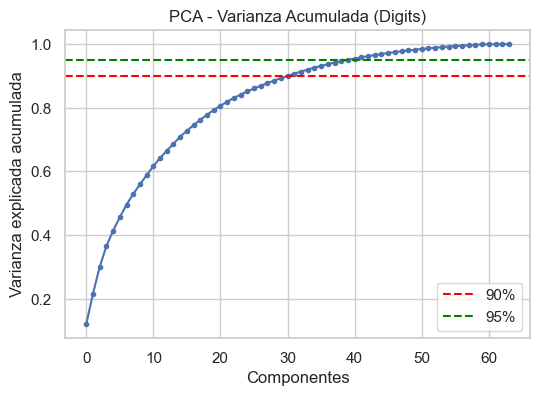

Componentes para 90%: 31
Componentes para 95%: 40


In [2]:
pca_full = PCA().fit(X_digits_scaled)
var_ratio = pca_full.explained_variance_ratio_
var_acum = np.cumsum(var_ratio)

plt.figure(figsize=(6,4))
plt.plot(var_acum, marker='o', ms=3)
plt.axhline(0.9, color='red', ls='--', label='90%')
plt.axhline(0.95, color='green', ls='--', label='95%')
plt.xlabel('Componentes')
plt.ylabel('Varianza explicada acumulada')
plt.legend()
plt.title('PCA - Varianza Acumulada (Digits)')
plt.show()

comp_90 = np.argmax(var_acum >= 0.90) + 1
comp_95 = np.argmax(var_acum >= 0.95) + 1
print('Componentes para 90%:', comp_90)
print('Componentes para 95%:', comp_95)

Elegir nº de componentes según trade-off precisión/compresión.

---
## 5. PCA 2D vs 3D para Visualización

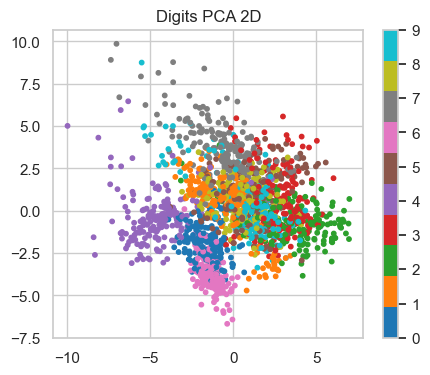

In [3]:
pca2 = PCA(n_components=2) # Reducir a 2D
X_pca2 = pca2.fit_transform(X_digits_scaled) # 2D

plt.figure(figsize=(5,4))
plt.scatter(X_pca2[:,0], X_pca2[:,1], c=y_digits, cmap='tab10', s=10)
plt.title('Digits PCA 2D')
plt.colorbar()
plt.show()

Observa cierto solapamiento: PCA es lineal y no optimiza separación de clases.

---
## 6. t-SNE sobre Digits (embedding 2D)
t-SNE preserva vecindarios locales modelando distribuciones de probabilidad. Sensible a parámetros y escalado.

t-SNE tiempo: 10.23s


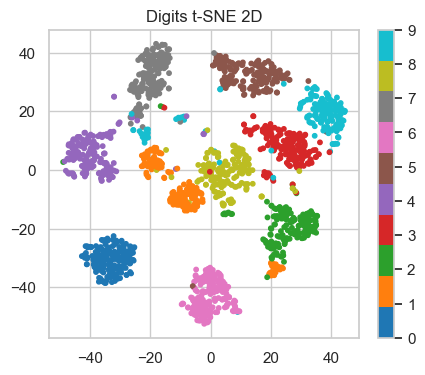

In [4]:
tsne = TSNE(n_components=2, perplexity=30, learning_rate='auto', init='pca', random_state=42)
t0 = time()
X_tsne = tsne.fit_transform(X_digits_scaled)
print(f't-SNE tiempo: {time()-t0:.2f}s')
plt.figure(figsize=(5,4))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y_digits, cmap='tab10', s=10)
plt.title('Digits t-SNE 2D')
plt.colorbar()
plt.show()

t-SNE tiende a separar más visualmente clusters, pero distancias globales no son interpretables.

---
## 7. UMAP (si disponible)

C:\Users\Jaf\AppData\Roaming\Python\Python313\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP tiempo: 11.94s


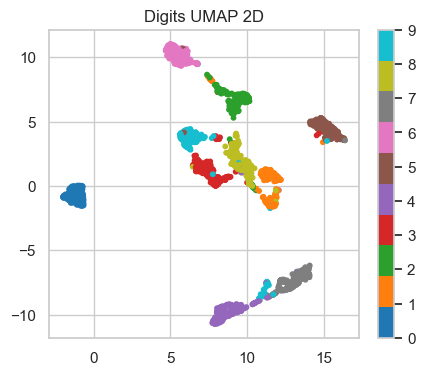

In [5]:
if UMAP_AVAILABLE:
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    t0 = time()
    X_umap = reducer.fit_transform(X_digits_scaled)
    print(f'UMAP tiempo: {time()-t0:.2f}s')
    plt.figure(figsize=(5,4))
    plt.scatter(X_umap[:,0], X_umap[:,1], c=y_digits, cmap='tab10', s=10)
    plt.title('Digits UMAP 2D')
    plt.colorbar()
    plt.show()
else:
    print('UMAP no instalado. Puedes instalar con: pip install umap-learn')

---
## 8. Manifold Swiss Roll: Isomap vs t-SNE vs UMAP

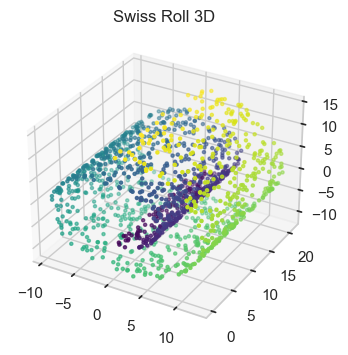

C:\Users\Jaf\AppData\Roaming\Python\Python313\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


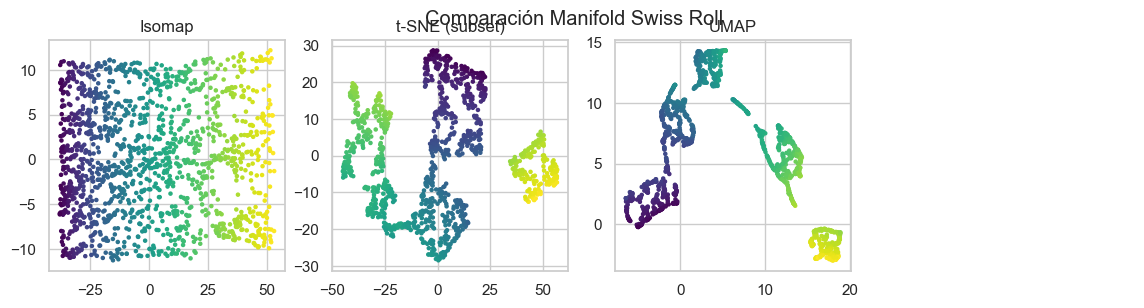

In [ ]:
# Visualización 3D original (opcional en 2D proyectado)
# Visualización 3D del Swiss Roll
# Axes3D del Swiss Roll, sirve para ver la estructura 3D original
# noqa: F401 evita advertencias de importación no utilizada
# Parámetros:
# X_swiss: datos 3D del Swiss Roll
# t_swiss: parámetro de coloración (posición en el rollo)

from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
fig = plt.figure(figsize=(5,4))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_swiss[:,0], X_swiss[:,1], X_swiss[:,2], c=t_swiss, cmap='viridis', s=5)
ax.set_title('Swiss Roll 3D')
plt.show()

# Isomap para desenrollar el Swiss Roll
iso = Isomap(n_neighbors=12, n_components=2)
X_iso = iso.fit_transform(X_swiss)

# t-SNE (subsample para velocidad)
idx = np.random.choice(len(X_swiss), size=1000, replace=False)
X_swiss_sub = X_swiss[idx]
t_sub = t_swiss[idx]
X_tsne_swiss = TSNE(n_components=2, perplexity=30, learning_rate='auto', init='pca', random_state=42).fit_transform(X_swiss_sub)

# UMAP (si disponible)
if UMAP_AVAILABLE:
    X_umap_swiss = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(X_swiss)

fig, axes = plt.subplots(1, 3 if not UMAP_AVAILABLE else 4, figsize=(14,3))
axes[0].scatter(X_iso[:,0], X_iso[:,1], c=t_swiss, cmap='viridis', s=5); axes[0].set_title('Isomap')
axes[1].scatter(X_tsne_swiss[:,0], X_tsne_swiss[:,1], c=t_sub, cmap='viridis', s=5); axes[1].set_title('t-SNE (subset)')
if UMAP_AVAILABLE:
    axes[2].scatter(X_umap_swiss[:,0], X_umap_swiss[:,1], c=t_swiss, cmap='viridis', s=5); axes[2].set_title('UMAP')
    axes[3].axis('off')
else:
    axes[2].axis('off')
plt.suptitle('Comparación Manifold Swiss Roll')
plt.show()

Isomap preserva estructura geodésica (desenrolla manifold). t-SNE/UMAP ofrecen embeddings que resaltan vecinos locales.

**Isomap**:

Desenrolla la forma global del conjunto de datos (como el Swiss Roll) al respetar la distancia a lo largo del “camino” del manifold.

*Resultado*: estructura global preservada.

**t-SNE / UMAP**:

Mantienen en la proyección quienes eran realmente vecinos, aunque la forma global se pierda.

*Resultado*: agrupaciones y proximidad local muy nítidas.

Esta diferencia es clave para elegir el algoritmo según lo que se quiera visualizar, analizar o modelar del conjunto de datos, especialmente en problemas de reducción de dimensionalidad con datos muy complejos.

---
## 9. Buenas Prácticas y Limitaciones ⚠️
- t-SNE: no usar para clustering automático; solo visual. t-SNE crea imágenes excelentes para descubrir grupos visuales, pero no genera asignaciones de cluster reproducibles ni una función para clasificar nuevos datos. No se debe usar el resultado directo de t-SNE como etiquetas para clustering real, sino solo para explorar visualmente relaciones locales.
- Ajustar perplexity según tamaño (regla: entre 5 y 50). “Perplexity” controla el número de vecinos considerados. Valores bajos (5-10) enfatizan microgrupos; valores altos (40-50) muestran patrones más globales. La regla práctica es mantenerlo entre 5 y 50 y probar varios valores para el dataset.
- UMAP: más rápido y escalable; reproducibilidad requiere random_state. UMAP puede visualizar datasets más grandes rápidamente y consumir menos memoria que t-SNE, además de preservarse mejor la estructura global. Como UMAP incluye pasos aleatorios, para obtener la misma visualización cada vez y compartir resultados, se recomienda definir el parámetro random_state.
- PCA antes de t-SNE/UMAP puede reducir ruido y acelerar. Realizar PCA para reducir el número de variables previas a t-SNE o UMAP elimina ruido y acelera el cálculo, especialmente en datos muy grandes o con muchas variables irrelevantes.
- Interpretar ejes de PCA: contribución de variables (component loadings). Los componentes principales de PCA son combinaciones de variables originales. Se pueden analizar las “component loadings” para descubrir qué variables contribuyen más a cada eje, ayudando a entender el significado de cada componente y facilitando la interpretación.

---
## 10. Ejercicio Guiado 📝
Sobre `digits`:
1. Aplica PCA reteniendo 95% varianza.
2. Sobre ese embedding reducido aplica t-SNE y compara tiempo vs t-SNE original.
3. Comenta diferencias visuales.
Completa la celda siguiente.

PCA 95% tiempo: 0.02s
Shape embedding 95%: (1797, 40)
t-SNE sobre PCA tiempo: 4.80s


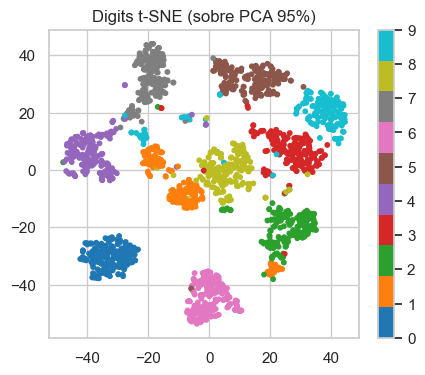

Comentario: Reducción previa acelera t-SNE y mantiene estructura visual comparable.


In [8]:
# SOLUCIÓN EJERCICIO GUIADO
# 1. PCA 95%
start = time()
pca95 = PCA(n_components=0.95, svd_solver='full')
X_pca95 = pca95.fit_transform(X_digits_scaled)
print(f'PCA 95% tiempo: {time()-start:.2f}s')
print('Shape embedding 95%:', X_pca95.shape)

# 2. t-SNE sobre embedding reducido
start = time()
X_tsne_pca = TSNE(n_components=2, perplexity=30, learning_rate='auto', init='pca', random_state=42).fit_transform(X_pca95)
print(f't-SNE sobre PCA tiempo: {time()-start:.2f}s')

plt.figure(figsize=(5,4))
plt.scatter(X_tsne_pca[:,0], X_tsne_pca[:,1], c=y_digits, cmap='tab10', s=10)
plt.title('Digits t-SNE (sobre PCA 95%)')
plt.colorbar()
plt.show()

print('Comentario: Reducción previa acelera t-SNE y mantiene estructura visual comparable.')

## 12. Resumen Final 🧾
En este notebook aprendiste:
- Motivación y taxonomía de técnicas de reducción de dimensionalidad.
- PCA: varianza explicada, selección de componentes, embedding.
- t-SNE, UMAP e Isomap para manifolds y visualización avanzada.
- Comparación empírica en Digits y Swiss Roll.
- Buenas prácticas (pipeline PCA + t-SNE/UMAP).
- Ejercicios para profundizar en interpretabilidad y rendimiento.

### Próximo paso:
Notebook 3.6: Reglas de Asociación y Análisis de la Cesta de la Compra.

**© IFCD093PO - Módulo 3.5**